In [1]:
import utils
import importlib
importlib.reload(utils)
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_and_clean_data, identify_arbitrage, apply_costs, plot_arbitrage

path = r"data/2026-04-06/option_chain_nifty_2026-04-07_full_history.csv"



In [2]:
df = load_and_clean_data(path)
df = identify_arbitrage(df)
df = apply_costs(df)

In [3]:
active_df = df[df['both_legs_liquid_time_pct'] >= 100]
active_df['strike_price'].unique()

array([22000, 22200, 22250, 22300, 22350, 22400, 22450, 22500, 22550,
       22600, 22650, 22700, 22750, 22800, 22850, 22900, 22950, 23000,
       23050, 23100, 23150, 23200, 23300, 23500])

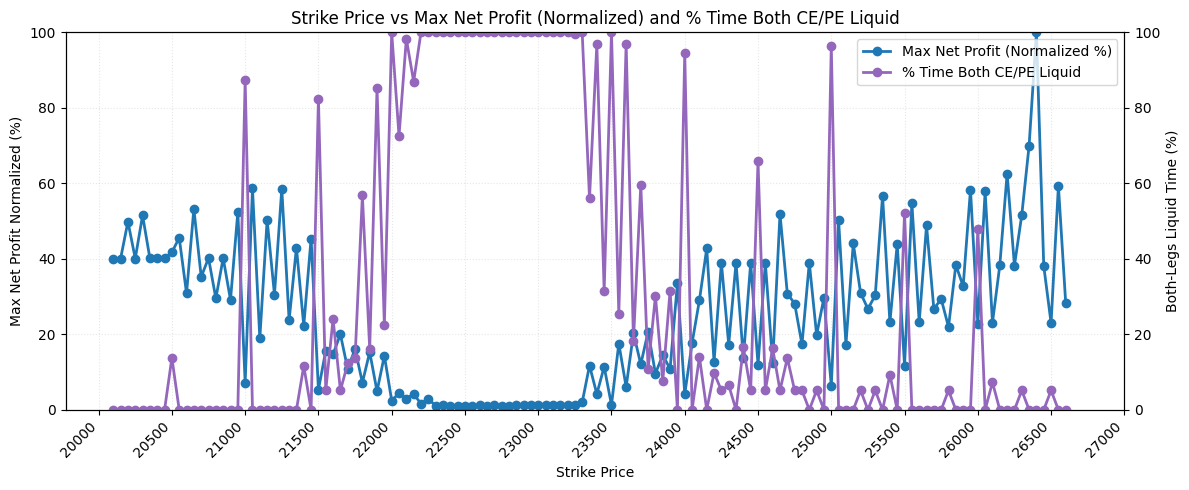

,strike_price,max_profit,max_profit_norm_pct,both_liquid_pct
0,20100,250.894717,40.071670,0.0
1,20150,250.883592,40.069893,0.0
2,20200,312.019560,49.834229,0.0
3,20250,250.961267,40.082299,0.0
4,20300,322.455238,51.500964,0.0


In [4]:
utils.plot_strike_vs_max_arbitrage_and_liquidity_pct(df, trading_cost=True).head()

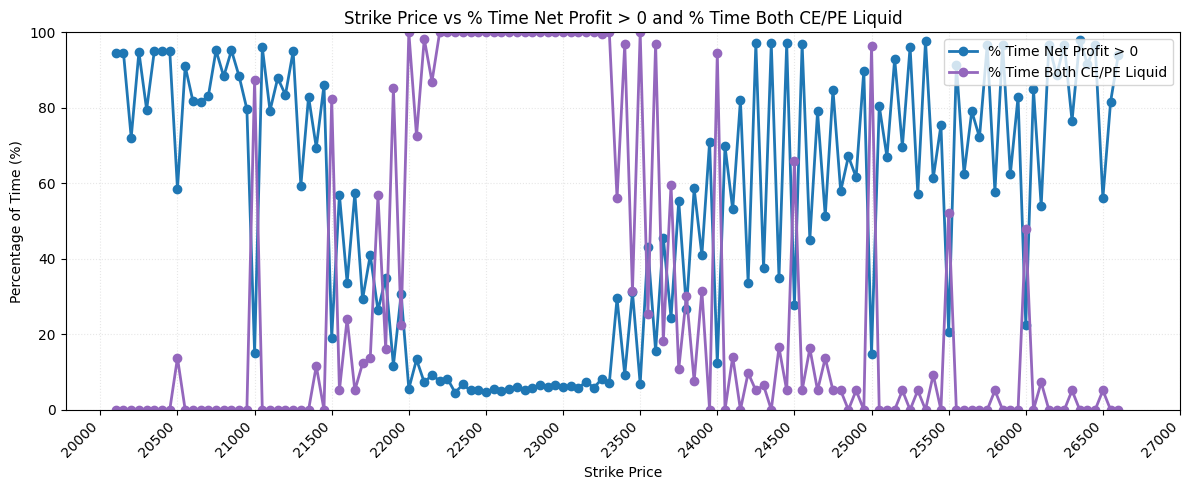

,strike_price,arbitrage_positive_pct,both_liquid_pct
0,20100,94.507846,0.0
1,20150,94.507846,0.0
2,20200,72.111270,0.0
3,20250,94.793153,0.0
4,20300,79.529244,0.0


In [5]:
utils.plot_strike_vs_arbitrage_positive_and_liquidity_pct(df, trading_cost=True).head()

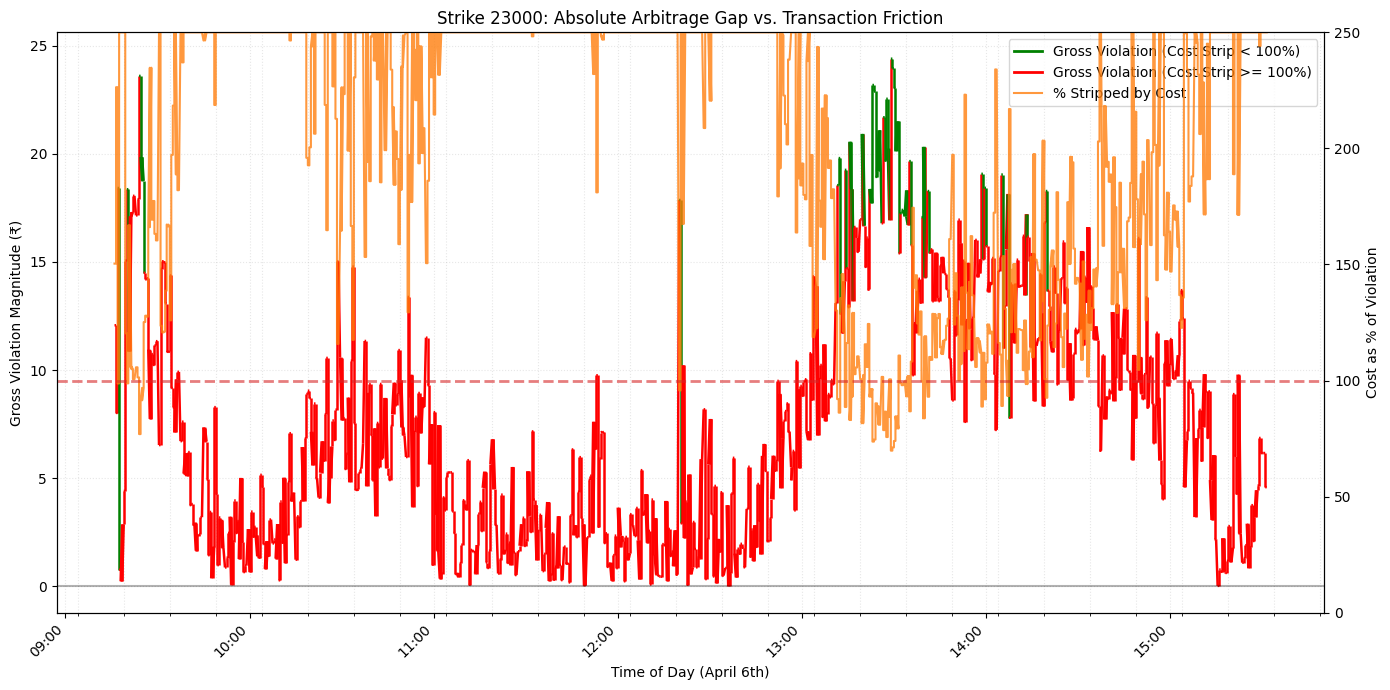

,fetch_time,abs_violation,cost,cost_stripped_pct
58,2026-04-06 09:16:00,12.070887,18.148378,150.348335
2023,2026-04-06 09:16:30,12.069575,18.146895,150.352396
2154,2026-04-06 09:16:30,8.019575,18.153453,226.364281
3988,2026-04-06 09:17:00,8.018262,18.151970,226.382839
4250,2026-04-06 09:17:00,18.418262,18.181876,98.716568
...,...,...,...,...
1452979,2026-04-06 15:30:30,6.162311,16.746130,271.750827
1454813,2026-04-06 15:31:00,6.163623,16.744643,271.668824
1454944,2026-04-06 15:31:00,4.586377,16.804161,366.392945
1456778,2026-04-06 15:31:30,4.585064,16.802674,366.465409


In [6]:
utils.plot_strike_abs_violation_vs_cost_stripped_pct(df, strike=23000)

In [7]:
importlib.reload(utils)

<module 'utils' from 'd:\\finmod\\Nifty50-PutCallParity-Arbitrage\\utils.py'>

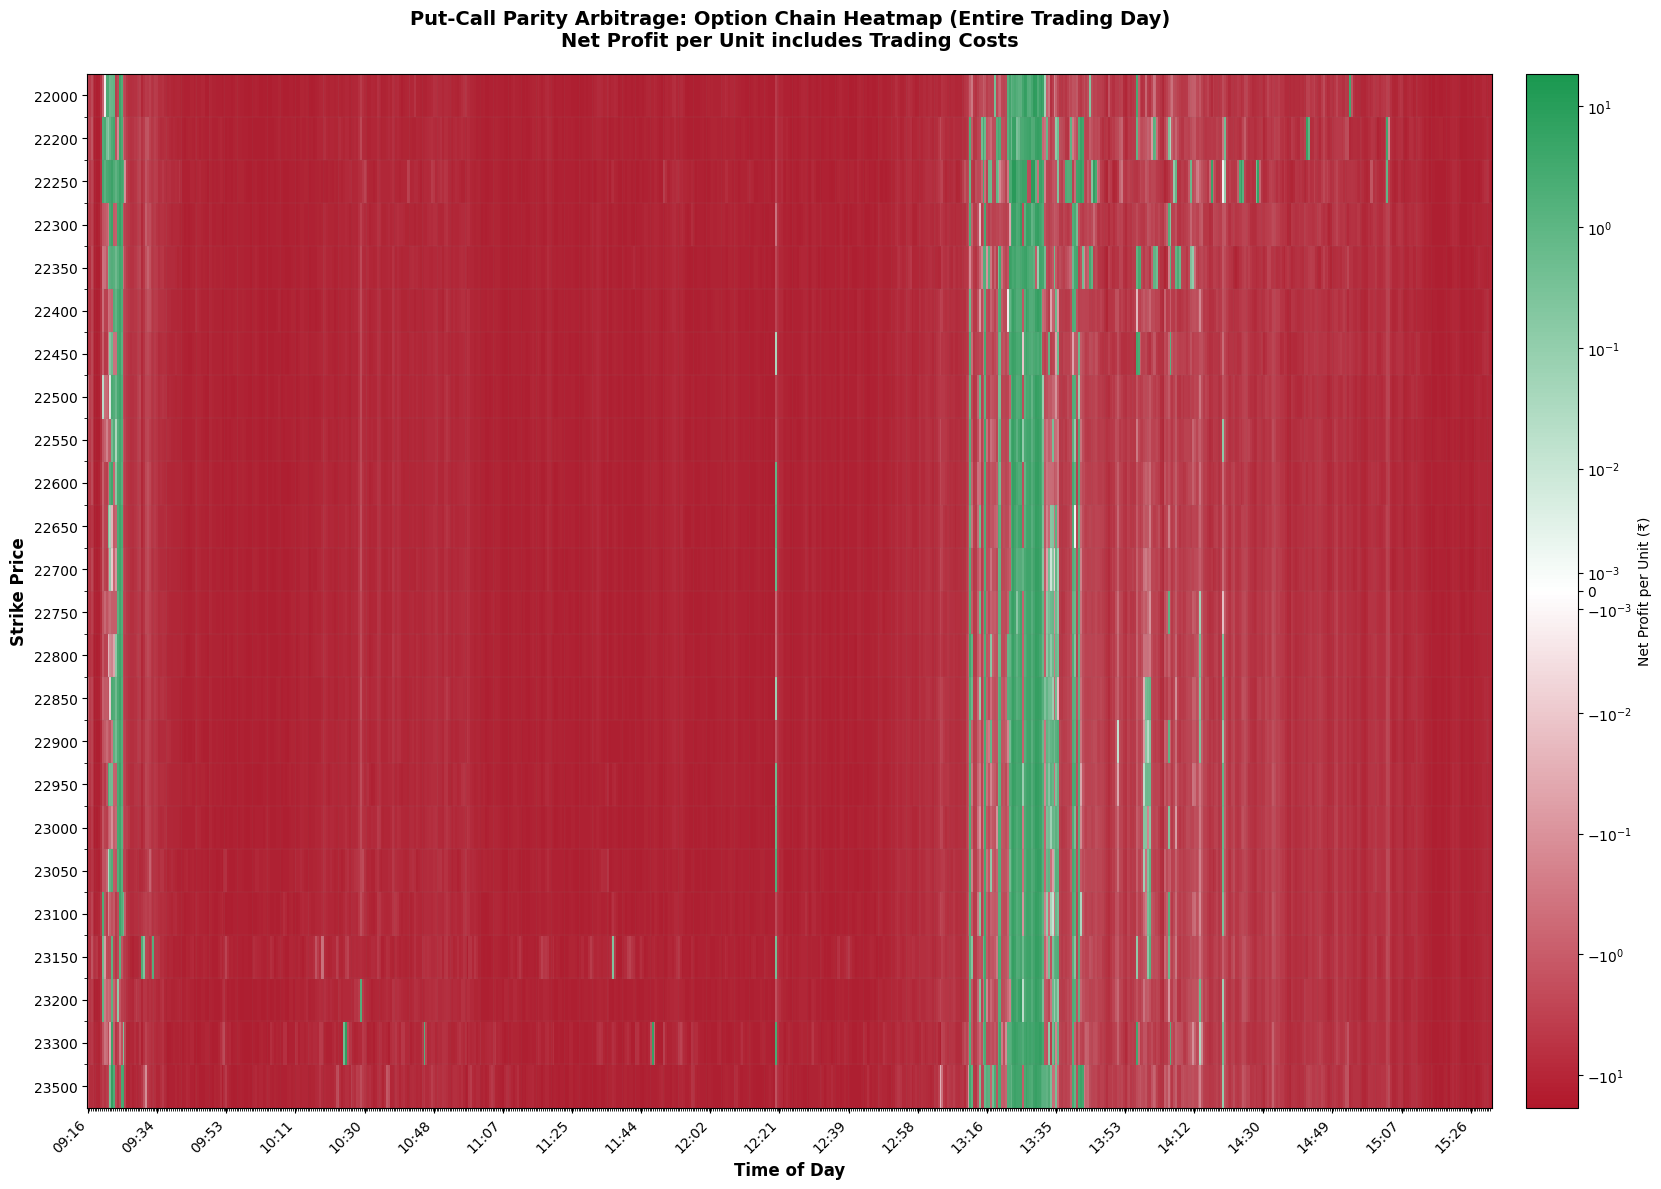

In [8]:
# COMPREHENSIVE HEATMAP: Entire Option Chain Over Entire Trading Day
# X-axis: Time of Day (09:15 to 15:30)
# Y-axis: Strike Prices (sorted)
# Color: Net Profit (Green=Profitable, Red=Loss, White=Break-even)

pivot_data = utils.plot_option_chain_heatmap_over_time(
    df[df['both_legs_liquid_time_pct'] >= 100],
    min_liquidity=0,  # Include all data (change to e.g., 500 for more liquid options)
    trading_cost=True,
    figsize=(18, 12),
    efficiency_band_pct=0.0001,  # Smaller neutral band for faster color transition
)

In [11]:
df.columns

Index(['fetch_time', 'symbol', 'expiry', 'spot_price', 'strike_price',
       'ce_growwContractId', 'ce_displayName', 'ce_longDisplayName',
       'ce_token', 'ce_marketLot', 'ce_liveData_close', 'ce_liveData_ltp',
       'ce_liveData_dayChange', 'ce_liveData_dayChangePerc', 'ce_liveData_oi',
       'ce_liveData_prevOI', 'ce_greeks_delta', 'ce_greeks_gamma',
       'ce_greeks_theta', 'ce_greeks_vega', 'ce_greeks_rho', 'ce_greeks_iv',
       'ce_greeks_pop', 'ce_markers', 'pe_growwContractId', 'pe_displayName',
       'pe_longDisplayName', 'pe_token', 'pe_marketLot', 'pe_liveData_close',
       'pe_liveData_ltp', 'pe_liveData_dayChange', 'pe_liveData_dayChangePerc',
       'pe_liveData_oi', 'pe_liveData_prevOI', 'pe_greeks_delta',
       'pe_greeks_gamma', 'pe_greeks_theta', 'pe_greeks_vega', 'pe_greeks_rho',
       'pe_greeks_iv', 'pe_greeks_pop', 'pe_markers', 'T', 'liquidity',
       'both_legs_liquid', 'both_legs_liquid_time_pct', 'market_side',
       'theoretical_side', 'violation